# Functional decay along the tree

Does a receptor's position in the phylogeny predict how many odorants it binds?

Every node — 432 reconstructed ancestors and 433 extant human receptors — is placed on
the rooted human tree, and its ligand count is plotted against its patristic distance
from the root. Ancestors and extant receptors share one axis, so a decay with depth
would show as a trend across both.

In [1]:
import sys
sys.path.append("../../scripts")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, kruskal, fisher_exact

from matplotlib.colors import ListedColormap, to_rgb
from matplotlib.patches import Patch
from plotting_functions import custom_plots, FIGSIZE
from ancestral_sets import load_ancestral, functional_groups, descriptors, odor_tags, \
                           decay_table, edge_table, node_topology, node_sets, \
                           save_fig, save_table, \
                           FG_SMARTS, DESCRIPTORS, PATTERN_ORDER, PATTERN_LABELS, TEN_NODES
plt.rcParams.update(custom_plots())

COMMON_COL, CLASS1_COL, CLASS2_COL = "#5F6A72", "#7f1734", "#557c99"
NODE_COL = {"common_ancestor": COMMON_COL, "class1_ancestor": CLASS1_COL, "class2_ancestor": CLASS2_COL}

anc = load_ancestral()
print(f"mode           : {anc.mode}")
print(f"ancestral cut  : median probability > {list(anc.per_node_cut.values())[0]:.2f}")
for node in anc.per_node_cut:
    print(f"  {node:<18} {int(anc.node_presence[node].sum())} ligands")
print(f"\nligands active in at least one node: {len(anc.all_smiles)}")

mode           : density
ancestral cut  : median probability > 0.89
  common_ancestor    21 ligands
  class1_ancestor    21 ligands
  class2_ancestor    8 ligands

ligands active in at least one node: 39


## Ligand count against distance from the root

In [2]:
decay = decay_table()          # None default = shared density fill
print(decay.groupby("kind").agg(n=("name", "size"),
                                median_ligands=("n_ligands", "median"),
                                median_distance=("distance", "median")).round(2).to_string())
save_table(decay, "03_ligands_vs_root_distance")

from scipy.stats import pearsonr, spearmanr
x, y = decay["distance"].to_numpy(), decay["n_ligands"].to_numpy()
r_p, p_p = pearsonr(x, y)
r_s, p_s = spearmanr(x, y)
print(f"\nall nodes   Pearson r = {r_p:+.3f}  p = {p_p:.3g}")
print(f"            Spearman r = {r_s:+.3f}  p = {p_s:.3g}")
for kind in ("ancestor", "extant"):
    sub = decay[decay.kind == kind]
    rp, pp = pearsonr(sub.distance, sub.n_ligands)
    print(f"{kind:<11} Pearson r = {rp:+.3f}  p = {pp:.3g}   (n={len(sub)})")

            n  median_ligands  median_distance
kind                                          
ancestor  432             7.0             3.68
extant    433             4.0             4.13

all nodes   Pearson r = +0.058  p = 0.0884
            Spearman r = -0.121  p = 0.000377
ancestor    Pearson r = +0.127  p = 0.00811   (n=432)
extant      Pearson r = -0.016  p = 0.743   (n=433)


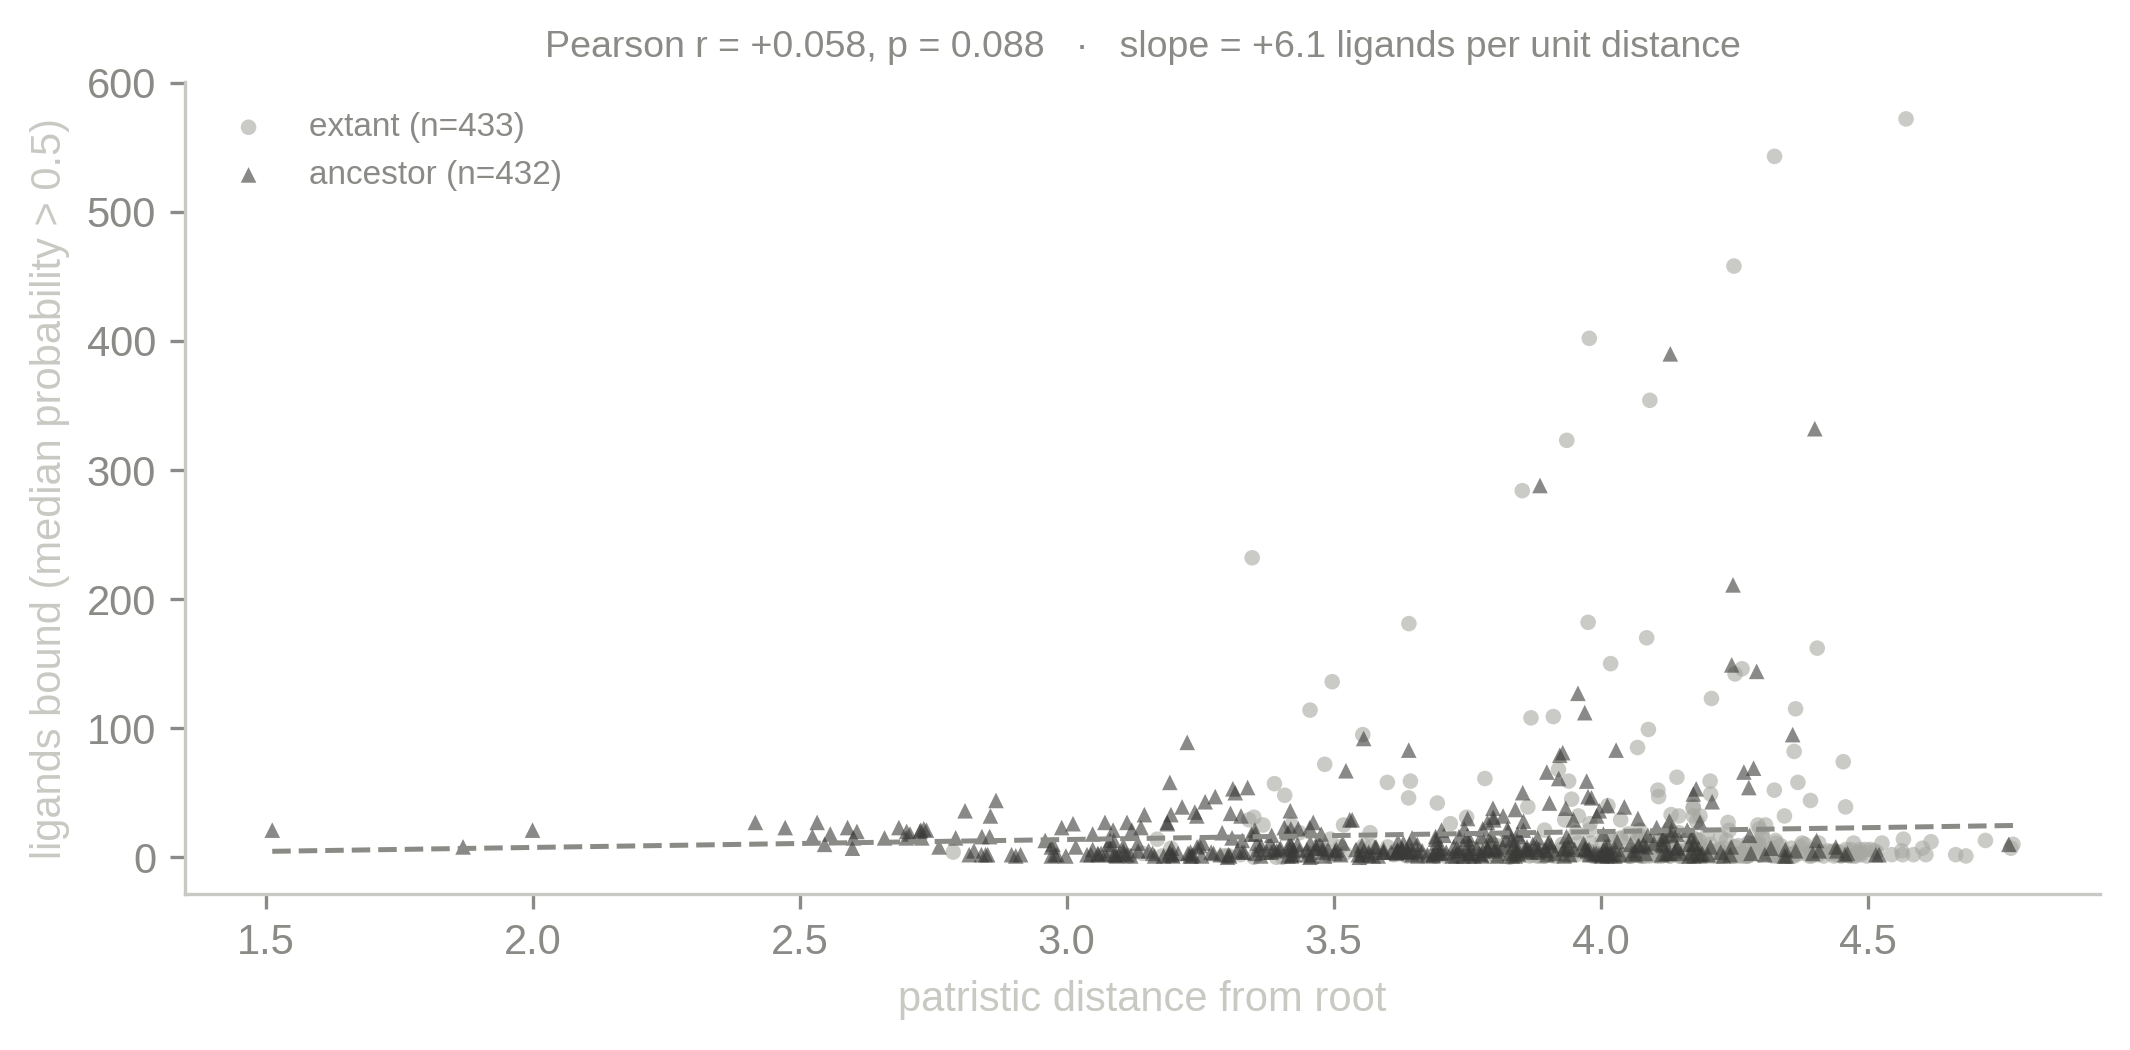

In [3]:
# Neutral greys, deliberately NOT the Class I/II palette: on these panels the split is
# ancestor vs extant, not receptor class, and reusing the class colours here read as a
# class contrast. The two groups are told apart by marker shape (triangle vs circle).
ANC_COL, EXT_COL = "#3a3a38", "#a8a8a3"

fig, ax = plt.subplots(figsize=(FIGSIZE[0] * 1.8, FIGSIZE[1] * 1.2))
for kind, colr, marker in [("extant", EXT_COL, "o"), ("ancestor", ANC_COL, "^")]:
    sub = decay[decay.kind == kind]
    ax.scatter(sub.distance, sub.n_ligands, s=14, alpha=0.6, color=colr,
               marker=marker, edgecolor="none", label=f"{kind} (n={len(sub)})")

slope, intercept = np.polyfit(x, y, 1)
xs = np.linspace(x.min(), x.max(), 100)
ax.plot(xs, slope * xs + intercept, color="#8a8a86", lw=1.2, ls="--")
ax.set_xlabel("patristic distance from root")
ax.set_ylabel("ligands bound (median probability > 0.5)")
ax.set_title(f"Pearson r = {r_p:+.3f}, p = {p_p:.2g}   ·   slope = {slope:+.1f} ligands per unit distance",
             fontsize=9)
ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); save_fig(fig, "03_ligands_vs_root_distance"); plt.show()

## Repertoire size, ancestors against extant receptors

The same counts without the distance axis, since the two groups sit at different depths
by construction.

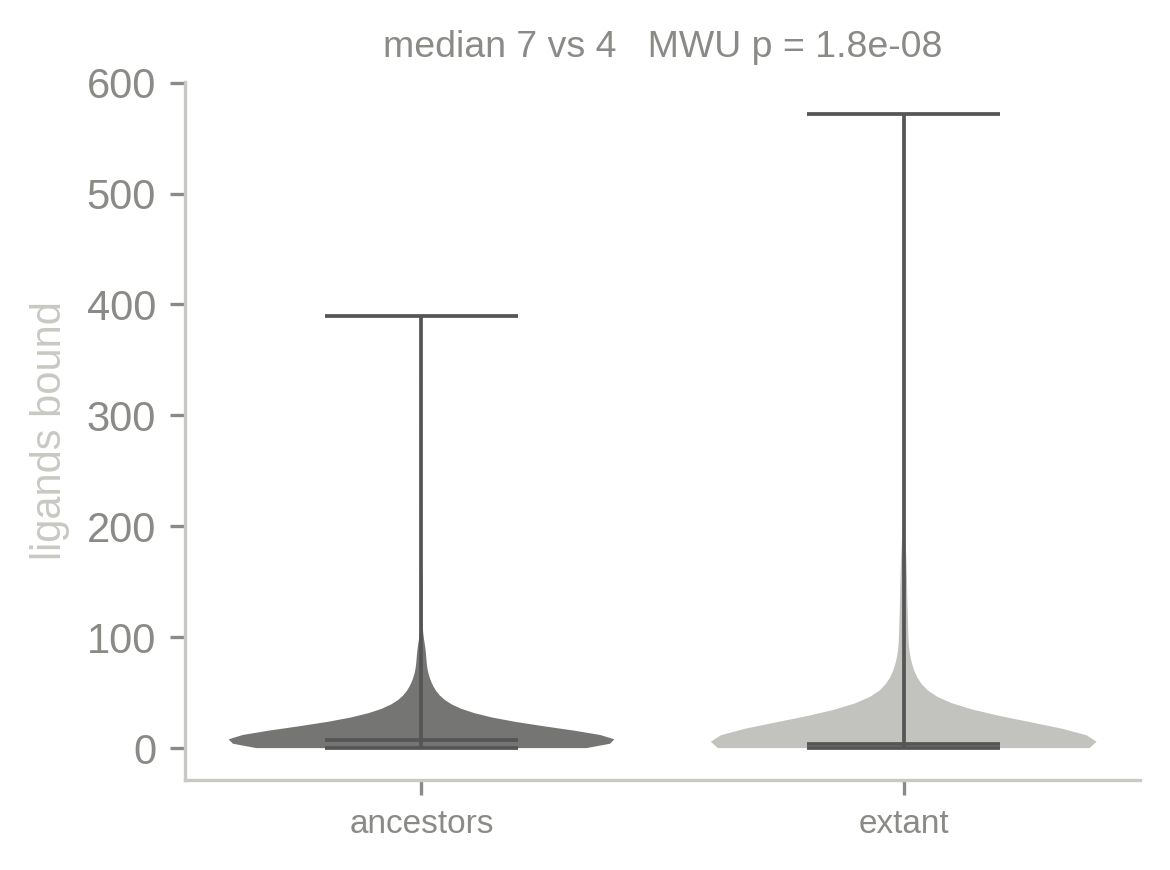

In [4]:
fig, ax = plt.subplots(figsize=FIGSIZE)
data = [decay.loc[decay.kind == k, "n_ligands"].values for k in ("ancestor", "extant")]
parts = ax.violinplot(data, showmedians=True, widths=0.8)
for pc, c in zip(parts["bodies"], [ANC_COL, EXT_COL]):
    pc.set_facecolor(c); pc.set_alpha(0.7); pc.set_edgecolor("none")
for key in ["cmedians", "cmaxes", "cmins", "cbars"]:
    parts[key].set_color("#555"); parts[key].set_linewidth(0.9)
u = mannwhitneyu(*data)
ax.set_xticks([1, 2]); ax.set_xticklabels(["ancestors", "extant"], fontsize=8)
ax.set_ylabel("ligands bound")
ax.set_title(f"median {np.median(data[0]):.0f} vs {np.median(data[1]):.0f}   MWU p = {u.pvalue:.2g}", fontsize=9)
plt.tight_layout(); save_fig(fig, "03_ancestor_vs_extant"); plt.show()